In [2]:
import nltk
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to C:\Users\SAHAJ
[nltk_data]     SONI\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to C:\Users\SAHAJ
[nltk_data]     SONI\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [3]:
data = {
    "Text": [
        "I love this product",
        "This is the worst experience ever",
        "The service was okay",
        "Amazing quality and great support",
        "I am very disappointed"
    ]
}

df = pd.DataFrame(data)
df


,Text
0,I love this product
1,This is the worst experience ever
2,The service was okay
3,Amazing quality and great support
4,I am very disappointed


In [4]:
import string
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = "".join([char for char in text if char not in string.punctuation])
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df["Clean_Text"] = df["Text"].apply(clean_text)
df


,Text,Clean_Text
0,I love this product,love product
1,This is the worst experience ever,worst experience ever
2,The service was okay,service okay
3,Amazing quality and great support,amazing quality great support
4,I am very disappointed,disappointed


In [5]:
def get_sentiment(text):
    analysis = TextBlob(text).sentiment.polarity
    if analysis > 0:
        return "Positive"
    elif analysis < 0:
        return "Negative"
    else:
        return "Neutral"

df["Sentiment"] = df["Clean_Text"].apply(get_sentiment)
df


,Text,Clean_Text,Sentiment
0,I love this product,love product,Positive
1,This is the worst experience ever,worst experience ever,Negative
2,The service was okay,service okay,Positive
3,Amazing quality and great support,amazing quality great support,Positive
4,I am very disappointed,disappointed,Negative


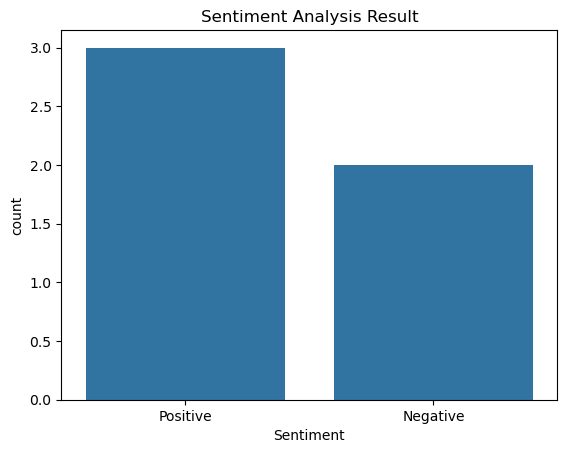

In [6]:
sns.countplot(x="Sentiment", data=df)
plt.title("Sentiment Analysis Result")
plt.show()


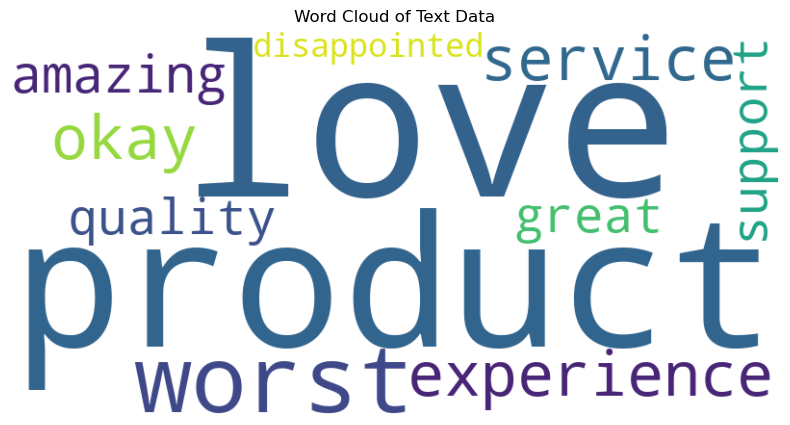

In [7]:
all_text = " ".join(df["Clean_Text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Text Data")
plt.show()


In [8]:
df


,Text,Clean_Text,Sentiment
0,I love this product,love product,Positive
1,This is the worst experience ever,worst experience ever,Negative
2,The service was okay,service okay,Positive
3,Amazing quality and great support,amazing quality great support,Positive
4,I am very disappointed,disappointed,Negative


In [9]:
!pip install nltk textblob matplotlib seaborn wordcloud pandas


In [10]:
import pandas as pd
import nltk
import string
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from textblob import TextBlob
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to C:\Users\SAHAJ
[nltk_data]     SONI\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\SAHAJ
[nltk_data]     SONI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
url = "https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv"

df = pd.read_csv(url, encoding='latin-1')
df.head()


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [12]:
df = df[['sentiment', 'tweet']]
df.columns = ['Label', 'Text']
df.head()


KeyError: "['sentiment'] not in index"

In [13]:
df.columns


Index(['id', 'label', 'tweet'], dtype='object')

In [14]:
df = df[['target', 'text']]
df.columns = ['Label', 'Text']
df.head()


KeyError: "None of [Index(['target', 'text'], dtype='object')] are in the [columns]"

In [15]:
df.head()


,id,label,tweet
0,1,0,@user when a father is dysfunctional and is s...
1,2,0,@user @user thanks for #lyft credit i can't us...
2,3,0,bihday your majesty
3,4,0,#model i love u take with u all the time in ...
4,5,0,factsguide: society now #motivation


In [16]:
df.columns


Index(['id', 'label', 'tweet'], dtype='object')

In [17]:
url = "https://raw.githubusercontent.com/campusx-official/ML-Datasets/main/twitter_sentiment.csv"
df = pd.read_csv(url)
df.head()


HTTPError: HTTP Error 404: Not Found

In [18]:
import pandas as pd
import random

positive_sentences = [
    "I love this product",
    "This is amazing",
    "Very happy with the service",
    "Excellent quality",
    "Highly recommended",
    "Absolutely fantastic experience",
    "Best purchase ever",
    "I am very satisfied",
    "Great performance",
    "Worth every penny"
]

negative_sentences = [
    "I hate this product",
    "Very disappointing",
    "Worst experience ever",
    "Poor quality",
    "Not recommended",
    "Terrible service",
    "Completely useless",
    "I am very unhappy",
    "Waste of money",
    "Extremely bad"
]

data = []

for _ in range(500):
    data.append(["Positive", random.choice(positive_sentences)])
    data.append(["Negative", random.choice(negative_sentences)])

df = pd.DataFrame(data, columns=["Label", "Text"])
df.head()


,Label,Text
0,Positive,Worth every penny
1,Negative,Not recommended
2,Positive,This is amazing
3,Negative,Worst experience ever
4,Positive,I love this product


In [19]:
df.shape


(1000, 2)

In [20]:
(1000, 2)


(1000, 2)

In [21]:
import nltk
import string
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = "".join(c for c in text if c not in string.punctuation)
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

df["Clean_Text"] = df["Text"].apply(clean_text)
df.head()


[nltk_data] Downloading package stopwords to C:\Users\SAHAJ
[nltk_data]     SONI\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,Label,Text,Clean_Text
0,Positive,Worth every penny,worth every penny
1,Negative,Not recommended,recommended
2,Positive,This is amazing,amazing
3,Negative,Worst experience ever,worst experience ever
4,Positive,I love this product,love product


In [22]:
from textblob import TextBlob

def predict_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity
    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

df["Predicted_Sentiment"] = df["Clean_Text"].apply(predict_sentiment)
df.head()


,Label,Text,Clean_Text,Predicted_Sentiment
0,Positive,Worth every penny,worth every penny,Positive
1,Negative,Not recommended,recommended,Neutral
2,Positive,This is amazing,amazing,Positive
3,Negative,Worst experience ever,worst experience ever,Negative
4,Positive,I love this product,love product,Positive


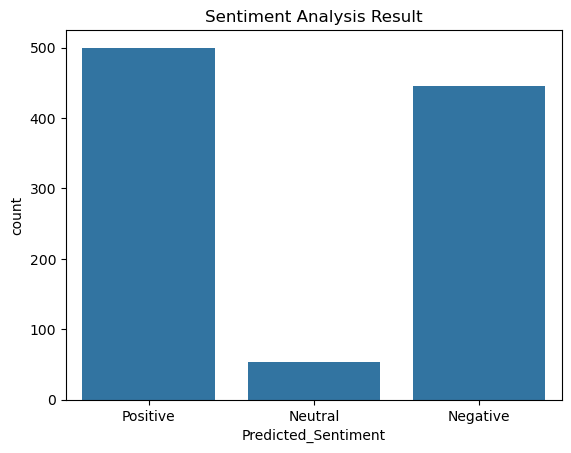

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Predicted_Sentiment", data=df)
plt.title("Sentiment Analysis Result")
plt.show()


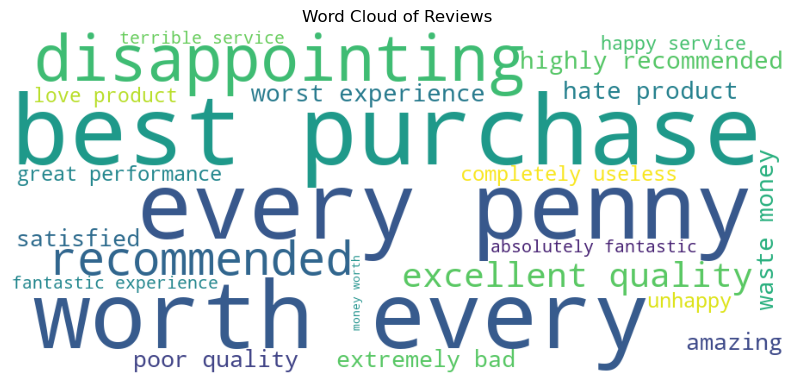

In [24]:
from wordcloud import WordCloud

text_data = " ".join(df["Clean_Text"])

wordcloud = WordCloud(
    width=900,
    height=400,
    background_color="white"
).generate(text_data)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Word Cloud of Reviews")
plt.show()


In [25]:
import os
os.getcwd()


'C:\\Users\\SAHAJ SONI'

In [26]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(df['Label'], df['Predicted_Sentiment']))


              precision    recall  f1-score   support

    Negative       1.00      0.89      0.94       500
     Neutral       0.00      0.00      0.00         0
    Positive       1.00      1.00      1.00       500

    accuracy                           0.95      1000
   macro avg       0.67      0.63      0.65      1000
weighted avg       1.00      0.95      0.97      1000



E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
E:\anaconda\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
df.to_csv("sentiment_results.csv", index=False)


In [28]:
def predict_single(text):
    clean = clean_text(text)
    return predict_sentiment(clean)

predict_single("The product is absolutely fantastic")


'Positive'